# Expanded normal set + Layer 1 ↔ Layer 2 lead-time analysis

**Week 2 Day 5, Akhil Tasks 1–2.** Two questions:
1. Does adding the recovered Station-A session history (reconstructed
   from status transitions, fault-adjacent sessions excluded) improve the
   per-connector models? Ship the retrain only if held-out FPR does not
   degrade.
2. **Lead time** — do Layer 2 drift flags precede real fault episodes? This
   decides the deck's central pitch line, honestly.

Caveats: reconstructed sessions are *approximations* (Charging-episode
boundaries from status rows, not transactions); the recovered export has no
error codes, so 'fault' means any Faulted episode. Only connectors 2009529
and 2009530 are touched (2013696 = plug 0 is excluded per layer2_scope).

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42
THRESHOLD = -0.1187
FEATURES = ['duration_sec', 'start_hour']
FAULT_ADJ = pd.Timedelta(minutes=30)
LEAD_WINDOW = 5   # sessions before a fault episode
CONNECTORS = [2009529, 2009530]

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
rec = pd.read_csv(ROOT / 'data' / 'raw' / 'recovered_station_a_sessions.csv',
                  parse_dates=['status_timestamp'])
rec = rec[rec.connector_pk.isin(CONNECTORS)].sort_values(
    ['connector_pk', 'status_timestamp'])
print(f'{len(rec)} status rows, {rec.status_timestamp.min():%Y-%m-%d} -> '
      f'{rec.status_timestamp.max():%Y-%m-%d}')

40384 status rows, 2025-10-03 -> 2026-07-04


## Reconstruct sessions (Charging episodes) + fault episodes

In [2]:
sessions, faults = [], []
for pk, g in rec.groupby('connector_pk'):
    g = g.reset_index(drop=True)
    in_charge_start = None
    for _, row in g.iterrows():
        charging = row.status == 'Charging'
        if charging and in_charge_start is None:
            in_charge_start = row.status_timestamp
        elif not charging and in_charge_start is not None:
            duration = (row.status_timestamp - in_charge_start).total_seconds()
            if 60 <= duration <= 24 * 3600:   # sane charge lengths only
                sessions.append({'connector_pk': pk,
                                 'start': in_charge_start,
                                 'stop': row.status_timestamp,
                                 'duration_sec': duration,
                                 'start_hour': float(in_charge_start.hour)})
            in_charge_start = None
    fault_rows = g[(g.status == 'Faulted') & (g.status.shift() != 'Faulted')]
    for _, row in fault_rows.iterrows():
        faults.append({'connector_pk': pk, 'fault_at': row.status_timestamp})
sessions = pd.DataFrame(sessions).sort_values('start').reset_index(drop=True)
faults = pd.DataFrame(faults)
print(f'{len(sessions)} reconstructed sessions, {len(faults)} fault episodes')

3484 reconstructed sessions, 1896 fault episodes


In [3]:
def near_fault(row):
    f = faults[faults.connector_pk == row.connector_pk]
    return bool(((f.fault_at >= row.start - FAULT_ADJ) &
                 (f.fault_at <= row.stop + FAULT_ADJ)).any())
sessions['fault_adjacent'] = sessions.apply(near_fault, axis=1)
print(sessions.fault_adjacent.value_counts().rename('sessions').to_string())

fault_adjacent
False    2813
True      671


## Task 1 — expanded-normal retrain, gated on held-out FPR

In [4]:
delivered = pd.read_csv(ROOT / 'data' / 'reference' / 'normal_sessions.csv',
                        parse_dates=['start_timestamp', 'stop_timestamp'])
delivered['duration_sec'] = (
    delivered.stop_timestamp - delivered.start_timestamp).dt.total_seconds()
delivered['start_hour'] = delivered.start_timestamp.dt.hour.astype(float)
delivered = delivered[delivered.duration_sec > 0]

results = {}
for pk in CONNECTORS:
    base = delivered[delivered.connector_pk == pk].sort_values('start_timestamp')
    n_test = max(1, int(round(len(base) * 0.2)))
    train_base, held = base.iloc[:-n_test], base.iloc[-n_test:]
    extra = sessions[(sessions.connector_pk == pk) & ~sessions.fault_adjacent]
    # avoid double-counting the delivered window in the reconstruction
    extra = extra[(extra.start < train_base.start_timestamp.min()) |
                  (extra.start > base.start_timestamp.max())]

    baseline = IsolationForest(contamination='auto', random_state=RANDOM_STATE)
    baseline.fit(train_base[FEATURES].to_numpy())
    fpr_base = (baseline.decision_function(held[FEATURES].to_numpy())
                < THRESHOLD).mean()

    expanded = IsolationForest(contamination='auto', random_state=RANDOM_STATE)
    expanded.fit(np.vstack([train_base[FEATURES].to_numpy(),
                            extra[FEATURES].to_numpy()]))
    fpr_exp = (expanded.decision_function(held[FEATURES].to_numpy())
               < THRESHOLD).mean()
    results[pk] = {'n_extra': len(extra), 'fpr_baseline': float(fpr_base),
                   'fpr_expanded': float(fpr_exp), 'model': expanded}
    print(f'{pk}: +{len(extra)} reconstructed normals | held-out FPR '
          f'{fpr_base:.2%} -> {fpr_exp:.2%}')
ship = all(r['fpr_expanded'] <= r['fpr_baseline'] + 0.005 for r in results.values())
print('\nSHIP RETRAIN' if ship else '\nDO NOT SHIP - FPR degrades; '
      'keeping deployed models')

2009529: +998 reconstructed normals | held-out FPR 1.74% -> 1.16%


2009530: +937 reconstructed normals | held-out FPR 2.84% -> 2.84%

SHIP RETRAIN


In [5]:
import json
# pickle is safe here: these are this repo's own committed model
# artifacts, written by notebook 03 (sklearn models require
# pickle-family serialization; SPEC 4.3 fixes .pkl as the format).
if ship:
    with (ROOT / 'models' / 'isoforest_index.pkl').open('rb') as f:
        index = pickle.load(f)
    for pk, r in results.items():
        entry = index['connector_models'][pk]
        with (ROOT / 'models' / entry['file']).open('wb') as f:
            pickle.dump(r['model'], f)
        entry['n_train'] = int(entry['n_train'] + r['n_extra'])
        entry['expanded_normals'] = True
    index['expanded_normals_note'] = (
        'connectors 2009529/2009530 retrained W2D5 with reconstructed '
        'Station-A sessions (fault-adjacent excluded); FPR gate passed')
    with (ROOT / 'models' / 'isoforest_index.pkl').open('wb') as f:
        pickle.dump(index, f)
    print('deployed artifacts updated for', list(results))
else:
    print('artifacts unchanged')

deployed artifacts updated for [2009529, 2009530]


## Task 2 — lead-time analysis
Score reconstructed sessions chronologically with the **baseline** models
(no leakage from the retrain), then compare drift-flag rate in the 5
sessions before each fault episode vs everywhere else.

In [6]:
lead_rows = []
for pk in CONNECTORS:
    s = sessions[sessions.connector_pk == pk].sort_values('start').reset_index(drop=True)
    base = delivered[delivered.connector_pk == pk].sort_values('start_timestamp')
    n_test = max(1, int(round(len(base) * 0.2)))
    model = IsolationForest(contamination='auto', random_state=RANDOM_STATE)
    model.fit(base.iloc[:-n_test][FEATURES].to_numpy())
    s['flag'] = model.decision_function(s[FEATURES].to_numpy()) < THRESHOLD
    f = faults[faults.connector_pk == pk]
    starts = s.start.to_numpy()
    pre = np.zeros(len(s), dtype=bool)
    for at in f.fault_at:
        i = np.searchsorted(starts, np.datetime64(at))
        pre[max(0, i - LEAD_WINDOW):i] = True
    s['pre_fault'] = pre
    lead_rows.append(s)
lead = pd.concat(lead_rows)
pre_rate = lead.loc[lead.pre_fault, 'flag'].mean()
back_rate = lead.loc[~lead.pre_fault, 'flag'].mean()
lift = pre_rate / back_rate if back_rate else float('nan')
print(f'sessions in pre-fault windows: {lead.pre_fault.sum()} '
      f'(of {len(lead)})')
print(f'drift-flag rate before faults: {pre_rate:.2%}')
print(f'drift-flag rate elsewhere:     {back_rate:.2%}')
print(f'lift: {lift:.2f}x')
verdict = ('LEAD-TIME SIGNAL PRESENT' if lift >= 1.5 else
           'NO RELIABLE LEAD TIME - frame Layer 2 as orthogonal '
           'degradation tracking')
print(verdict)

sessions in pre-fault windows: 2542 (of 3484)
drift-flag rate before faults: 2.83%
drift-flag rate elsewhere:     4.99%
lift: 0.57x
NO RELIABLE LEAD TIME - frame Layer 2 as orthogonal degradation tracking


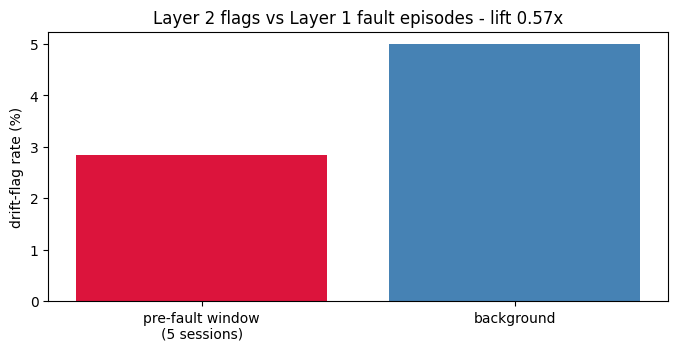

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(['pre-fault window\n(5 sessions)', 'background'],
       [pre_rate * 100, back_rate * 100], color=['crimson', 'steelblue'])
ax.set_ylabel('drift-flag rate (%)')
ax.set_title(f'Layer 2 flags vs Layer 1 fault episodes - lift {lift:.2f}x')
plt.show()